# Vorrechenübung 1: Zeitintegration

![alt text](pendel.png)

Unter Annahme eines masselosen Seils und einer konzetrierten Punktmasse, kann ein Pendel mit der dargestellten DGL beschrieben werden. Für kleine Winkel kann diese DGL linearisiert und analytisch im Zeitbereich gelöst werden. Für größere Auslenkungen existiert jedoch keine analytische Lösung. Hier können numerische Zeitintegrationsverfahren Aufschluss geben. 
Gegeben sind die Anfangsbedingungen $\phi_0 = \frac{\pi}{4}$ und $v_0 = 0$.

Die Themen dieser Vorrechenübung sind:
* Explizites Euler-Verfahren
* Implizites Euler-Verfahren
* Symplektisches Euler-Verfahren
* Trapezregel
* Konservativität der Zeitintegrationsverfahren
* Einfluss der Zeitschrittgröße auf die Konvergenz

Zunächst wird die DGL auf ein System 1. Ordnung gebracht:\
$\dot{\phi}(t) = v(t)$\
$\dot{v}(t) = -\frac{g}{L}sin(\phi(t))$

**Hinweis** : Im Code wurde $\boldsymbol{x} = \begin{pmatrix} \phi \\ v \end{pmatrix}$ gesetzt.

In [1]:
import numpy as np
from scipy.optimize import fsolve
from helper_functions import plot_motion
from helper_functions import plot_energy
from helper_functions import plot_convergence

## Modellparameter

In [2]:
g = 9.81                        # gravity acceleration in m/s^2
L = 1.0                         # pendulum length in m
delta_t = 0.05                  # time step in s
T = 10                          # simulation time in s
N = round(T/delta_t)            # number of evaluations
m = 1                           # mass in kg

phi_0 = np.pi/4                 # initial angle phi in rad
v_0 = 0                         # initial velocity v in rad/s
x = np.zeros((N + 1, 2))        # preallocate array
x[0] = [phi_0, v_0]             # set initial conditions
t = np.linspace(0, T, N + 1)    # timestamps to evaluate

## Explizites Euler-Verfahren

Einsetzen der DGL (System erster Ordnung) in die Formeln führt auf das folgende nichtlineare Gleichungssystem 

$\phi_{n+1} = \phi_n + v_n \cdot \Delta t\\$
$v_{n+1} = v_n - \frac{g}{L}sin(\phi_n) \Delta t$

Linearisieren von $v$ ergibt
$\\v_{n+1} = v_n - \frac{g}{L}\phi_n \Delta t$

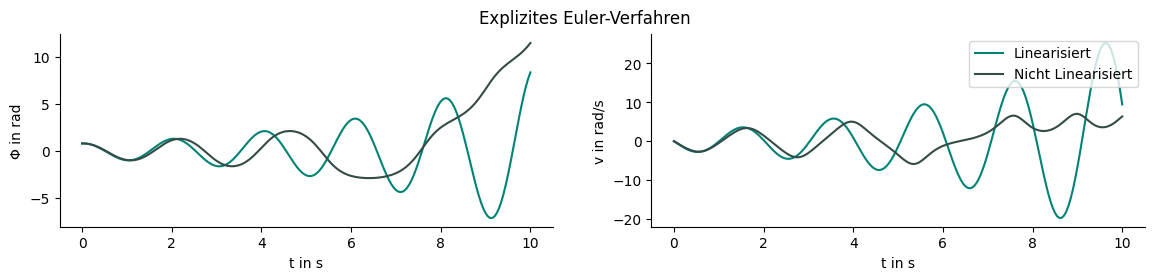

In [3]:

# Preallocate arrays 
x_ee = x.copy()
x_ee_nonlinear = x.copy()

# Define functions f(t_k, y_k)
# Linearized Case
f_ee  = lambda x: np.array([x[1], -g/L * x[0]])

# Nonlinearized Case
f_nonlinear_ee = lambda x: np.array([x[1], -g/L * np.sin(x[0])])

# Evaluate for each time step
for n in range(N):
    # Linearized Case
    x_ee[n+1] = x_ee[n] + f_ee(x_ee[n]) * delta_t

    # Nonlinearized Case
    x_ee_nonlinear[n+1] = x_ee_nonlinear[n] + f_nonlinear_ee(x_ee_nonlinear[n])* delta_t

# Plot results
plot_motion(t, x_ee, x_ee_nonlinear, "Explizites Euler-Verfahren")

### Energieerhaltung mit dem expliziten Euler-Verfahren

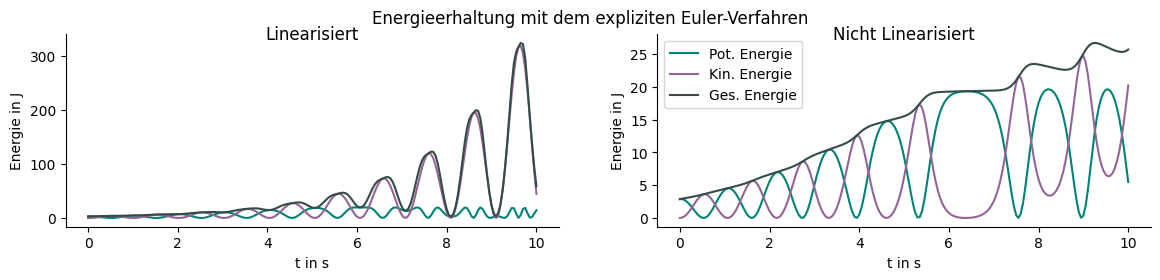

In [4]:
# Conservation of Energy
E_pot = [m * g * (L- np.cos(phi)) for phi in x_ee[:, 0]]
E_kin = [0.5 * m * (L**2) * v**2 for v in x_ee[:, 1]]
E_total = [e_pot + e_kin for e_pot, e_kin in zip(E_pot, E_kin)]

E_pot_nonlinear = [m * g * (L- np.cos(phi)) for phi in x_ee_nonlinear[:, 0]]
E_kin_nonlinear = [0.5 * m * (L**2) * v**2 for v in x_ee_nonlinear[:, 1]]
E_total_nonlinear = [e_pot + e_kin for e_pot, e_kin in zip(E_pot_nonlinear, E_kin_nonlinear)]

# Plot results
plot_energy(t, E_pot, E_kin, E_total, E_pot_nonlinear, E_kin_nonlinear, E_total_nonlinear, "Energieerhaltung mit dem expliziten Euler-Verfahren")

## Implizites Euler-Verfahren

Einsetzen der DGL in die Formeln führt auf das folgende nichtlineare Gleichungssystem
$\\0 = \phi_{n+1} - \phi_n - v_{n+1} \cdot \Delta t\\$
$0 = v_{n+1} - v_n + \frac{g}{L}sin(\phi_{n+1}) \Delta t$

Linearisieren von $v$ führt auf das lineare Gleichungssystem
$\\0 = \phi_{n+1} - \phi_n - v_{n+1} \cdot \Delta t\\$
$0 = v_{n+1} - v_n + \frac{g}{L}\phi_{n+1} \Delta t$

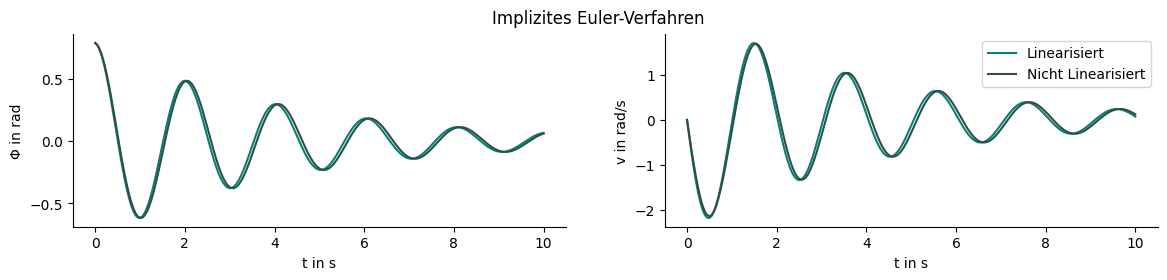

In [5]:
# Preallocate arrays 
x_ie = x.copy()
x_ie_nonlinear = x.copy()

# Define functions f(t_k+1, y_k+1) and system of equations
# Linearized case
A = np.array([[0, 1], [-g/L, 0]])
f_ie = lambda x: A @ x
sys_of_eq_ie = lambda x_k_1, x_k: x_k_1 - x_k - delta_t * f_ie(x_k_1)                         # = 0

# Nonlinearized case
f_nonlinear_ie = lambda x: np.array([x[1], -g/L * np.sin(x[0])])
sys_of_eq_nonlinear_ie = lambda x_k_1, x_k: x_k_1 - x_k - delta_t * f_nonlinear_ie(x_k_1)     # = 0

# Evaluate for each time step
for n in range(N):
    # Linearized case
    x_ie[n+1] = fsolve(sys_of_eq_ie, x_ie[n], args=(x_ie[n]))

    # Nonlinearized Case
    x_ie_nonlinear[n+1] = fsolve(sys_of_eq_nonlinear_ie, x_ie_nonlinear[n], args=(x_ie_nonlinear[n]))

# Plot results
plot_motion(t, x_ie, x_ie_nonlinear, "Implizites Euler-Verfahren")

### Energieerhaltung mit dem impliziten Euler-Verfahren

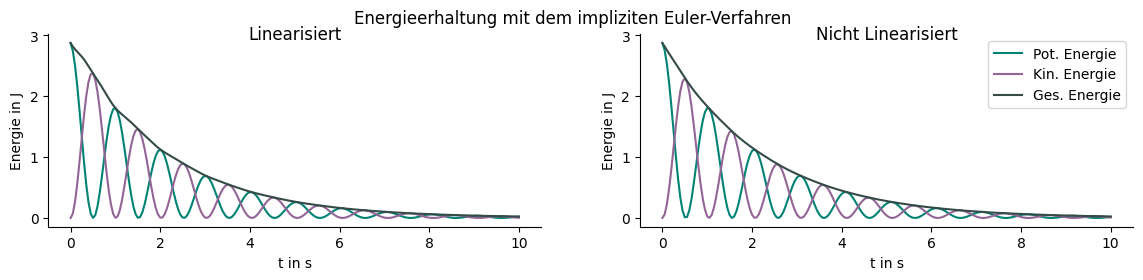

In [6]:
# Conservation of Energy
E_pot = [m * g * (L- np.cos(phi)) for phi in x_ie[:, 0]]
E_kin = [0.5 * m * (L**2) * v**2 for v in x_ie[:, 1]]
E_total = [e_pot + e_kin for e_pot, e_kin in zip(E_pot, E_kin)]

E_pot_nonlinear = [m * g * (L- np.cos(phi)) for phi in x_ie_nonlinear[:, 0]]
E_kin_nonlinear = [0.5 * m * (L**2) * v**2 for v in x_ie_nonlinear[:, 1]]
E_total_nonlinear = [e_pot + e_kin for e_pot, e_kin in zip(E_pot_nonlinear, E_kin_nonlinear)]

# Plot results
plot_energy(t, E_pot, E_kin, E_total, E_pot_nonlinear, E_kin_nonlinear, E_total_nonlinear, "Energieerhaltung mit dem impliziten Euler-Verfahren")

## Symplektisches Euler-Verfahren

Einsetzen der DGL in die Formeln führt auf das folgende nichtlineare Gleichungssystem
$\\0 = \phi_{n+1} - \phi_n - v_{n} \cdot \Delta t\\$
$0 = v_{n+1} - v_n + \frac{g}{L}sin(\phi_{n+1}) \Delta t$

Linearisieren von $v$ führt auf das lineare Gleichungssystem
$\\0 = \phi_{n+1} - \phi_n - v_{n} \cdot \Delta t\\$
$0 = v_{n+1} - v_n + \frac{g}{L}\phi_{n+1} \Delta t$

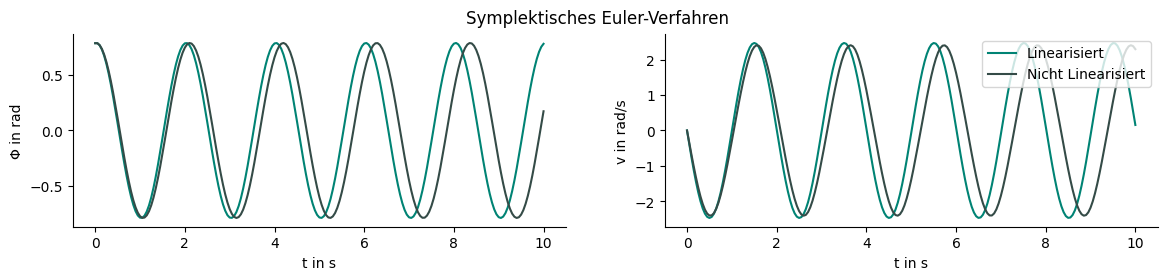

In [7]:
# Preallocate arrays 
x_se = x.copy()
x_se_nonlinear = x.copy()

# Define functions f(t_k+1, y_k+1) and system of equations
# Linearized case
f_1_se = lambda x: x[1]
f_2_se = lambda x: -g/L * x[0]
sys_of_eq_se = lambda x_k_1, x_k: x_k_1 - x_k - delta_t * np.array([f_1_se(x_k), f_2_se(x_k_1)])                                 # = 0   

# Nonlinearized case
f_1_nonlinear_se = lambda x_k: x_k[1]
f_2_nonlinear_se = lambda x_k_1: -g/L * np.sin(x_k_1[0])
sys_of_eq_nonlinear_se = lambda x_k_1, x_k: x_k_1 - x_k - delta_t * np.array([f_1_nonlinear_se(x_k), f_2_nonlinear_se(x_k_1)])   # = 0

# Evaluate for each time step
for n in range(N):
    # Linearized case
    x_se[n+1] = fsolve(sys_of_eq_se, x_se[n], args=(x_se[n]))

    # Nonlinearized Case
    x_se_nonlinear[n+1] = fsolve(sys_of_eq_nonlinear_se, x_se_nonlinear[n], args=(x_se_nonlinear[n]))

# Plot results
plot_motion(t, x_se, x_se_nonlinear, "Symplektisches Euler-Verfahren")

### Energieerhaltung mit dem symplektischen Euler-Verfahren

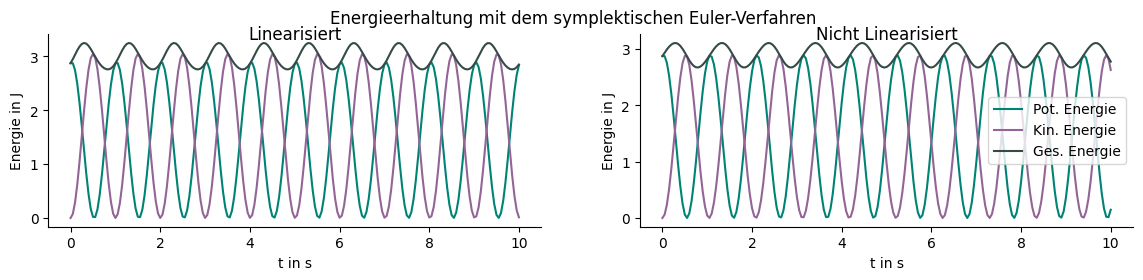

In [8]:
# Conservation of Energy
E_pot = [m * g * (L- np.cos(phi)) for phi in x_se[:, 0]]
E_kin = [0.5 * m * (L**2) * v**2 for v in x_se[:, 1]]
E_total = [e_pot + e_kin for e_pot, e_kin in zip(E_pot, E_kin)]

E_pot_nonlinear = [m * g * (L- np.cos(phi)) for phi in x_se_nonlinear[:, 0]]
E_kin_nonlinear = [0.5 * m * (L**2) * v**2 for v in x_se_nonlinear[:, 1]]
E_total_nonlinear = [e_pot + e_kin for e_pot, e_kin in zip(E_pot_nonlinear, E_kin_nonlinear)]

# Plot results
plot_energy(t, E_pot, E_kin, E_total, E_pot_nonlinear, E_kin_nonlinear, E_total_nonlinear, "Energieerhaltung mit dem symplektischen Euler-Verfahren")

## Trapezregel

Einsetzen der DGL in die Formeln führt auf das folgende nichtlineare Gleichungssystem
$\\0 = \phi_{n+1} - \phi_n - (v_{n} + v_{n+1}) \cdot \frac{\Delta t}{2}\\$
$0 = v_{n+1} - v_n + \frac{g}{L}(sin(\phi_{n}) + sin(\phi_{n+1})) \frac{\Delta t}{2}$

Linearisieren von $v$ führt auf das lineare Gleichungssystem
$\\0 = \phi_{n+1} - \phi_n - (v_{n} + v_{n+1}) \cdot \frac{\Delta t}{2}\\$
$0 = v_{n+1} - v_n + \frac{g}{L}(\phi_n + \phi_{n+1}) \cdot \frac{\Delta t}{2}$

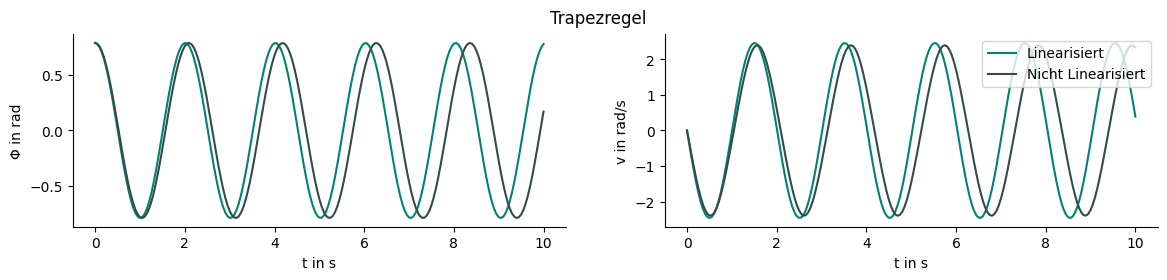

In [9]:
# Preallocate arrays 
x_tr = x.copy()
x_tr_nonlinear = x.copy()

# Define functions f(t_k+1, y_k+1) and system of equations
# Linearized case
A = np.array([[0, 1], [-g/L, 0]])
f_tr = lambda x: A @ x
sys_of_eq_tr = lambda x_k_1, x_k: x_k_1 - x_k - delta_t/2 * (f_tr(x_k_1) + f_tr(x_k))                                   # = 0

# Nonlinearized case
f_nonlinear_tr = lambda x: np.array([x[1], -g/L * np.sin(x[0])])
sys_of_eq_nonlinear_tr = lambda x_k_1, x_k: x_k_1 - x_k - delta_t/2 * (f_nonlinear_tr(x_k_1) + f_nonlinear_tr(x_k))     # = 0

# Evaluate for each time step
for n in range(N):
    # Linearized case
    x_tr[n+1] = fsolve(sys_of_eq_tr, x_tr[n], args=(x_tr[n]))

    # Nonlinearized Case
    x_tr_nonlinear[n+1] = fsolve(sys_of_eq_nonlinear_tr, x_tr_nonlinear[n], args=(x_tr_nonlinear[n]))

# Plot results
plot_motion(t, x_tr, x_tr_nonlinear, "Trapezregel")

### Energieerhaltung mit der Trapezregel

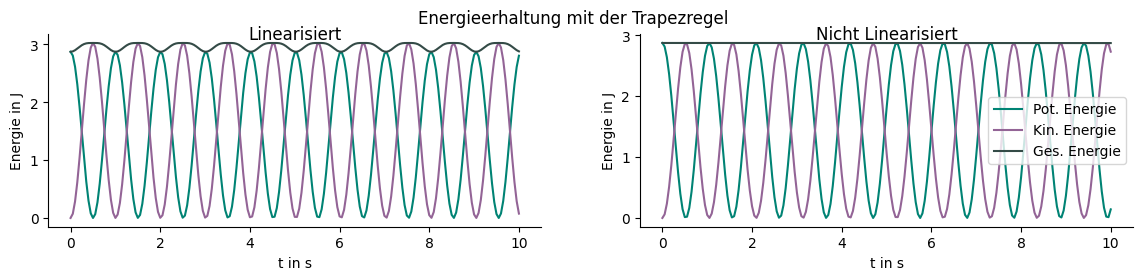

In [10]:
# Conservation of Energy
E_pot = [m * g * (L- np.cos(phi)) for phi in x_tr[:, 0]]
E_kin = [0.5 * m * (L**2) * v**2 for v in x_tr[:, 1]]
E_total = [e_pot + e_kin for e_pot, e_kin in zip(E_pot, E_kin)]

E_pot_nonlinear = [m * g * (L- np.cos(phi)) for phi in x_tr_nonlinear[:, 0]]
E_kin_nonlinear = [0.5 * m * (L**2) * v**2 for v in x_tr_nonlinear[:, 1]]
E_total_nonlinear = [e_pot + e_kin for e_pot, e_kin in zip(E_pot_nonlinear, E_kin_nonlinear)]

# Plot results
plot_energy(t, E_pot, E_kin, E_total, E_pot_nonlinear, E_kin_nonlinear, E_total_nonlinear, "Energieerhaltung mit der Trapezregel")

## Konvergenzanalyse
Für die Konvergenz der Zeitintegration ist die Größe der Zeitschritte und die Ordnung des Verfahrens ausschlaggebend. Im Folgenden wird daher die linearisierte Gleichung mit verschiedenen numerischen Verfahren und veränderlichen Zeitschritten ausgewertet und mit der analytischen Lösung verglichen. 

C:\Users\phili\AppData\Local\Temp\ipykernel_13892\2823583387.py:21: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  x_tr[n+1] = fsolve(sys_of_eq_tr, x_tr[n], args=(x_tr[n]))


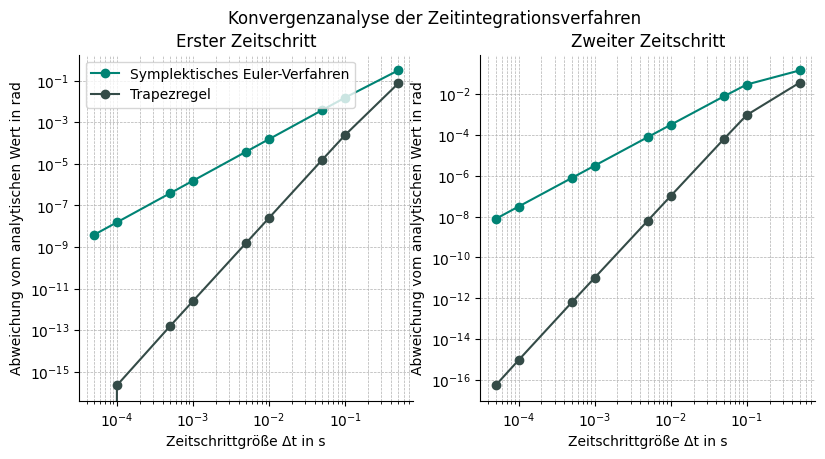

In [ ]:
timesteps = [0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001, 0.00005]
N = 2                                           # Number of time steps
x = np.zeros((N+1, 2))
x[0] = [np.pi/10, v_0]                          # Note: Small initial angle
error_se = np.zeros((len(timesteps), N+1))
error_tr = np.zeros((len(timesteps), N+1))

# Iterate over each step size
for idx, delta_t in enumerate(timesteps):
    # reset the arrays
    x_tr = x.copy()
    x_se = x.copy()
    analyt_phi = x.copy()
    
    for n in range(N):
        # calculate analytical solution
        omega = (g/L)**0.5
        analyt_phi[n+1] = analyt_phi[0]*np.cos(omega*delta_t*(n+1))

        # Calculate numeric solutions
        x_tr[n+1] = fsolve(sys_of_eq_tr, x_tr[n], args=(x_tr[n]))
        x_se[n+1] = fsolve(sys_of_eq_se, x_se[n], args=(x_se[n]))
    
    # Calculate difference between numeric and analytical solution
    error_se[idx] = abs(x_se[:, 0] - analyt_phi[:, 0])
    error_tr[idx] = abs(x_tr[:, 0] - analyt_phi[:, 0])

plot_convergence(timesteps, error_se, error_tr)    